<a href="https://colab.research.google.com/github/Sahilkahlon03-cmyk/ecommerce-data-analysis/blob/main/M515_House_Price_Prediction_with_Fairness_Notebook_1_Data_Exploration_%26_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"""
M515: House Price Prediction with Fairness - Notebook 1
Data Exploration & EDA
"""

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import warnings

In [104]:
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [105]:
try:
    housing = fetch_california_housing()  # Note: sklearn has no `load_california_housing` - only `fetch_...`, which needs the network.
    df = pd.DataFrame(housing.data, columns=housing.feature_names)
    df['target'] = housing.target
except Exception as err:
    print(f"Download unavailable ({type(err).__name__}), reading local CSV instead.")
    df = pd.read_csv('california_housing.csv')
    # The saved file calls the target column 'Price'; the rest of the pipeline
    # expects 'target'.
    if 'Price' in df.columns:
        df = df.rename(columns={'Price': 'target'})


In [106]:
print(f"Loaded: {df.shape[0]:,} samples, {len(df.columns)} features")
print(f"Missing values: {df.isnull().sum().sum()}")


Loaded: 20,640 samples, 9 features
Missing values: 0


# Correlation with target

In [107]:
correlation = df.corr()['target'].sort_values(ascending=False)
print(f"Top features: {correlation.index[1:4].tolist()}")

Top features: ['MedInc', 'AveRooms', 'HouseAge']


# Visualizations

In [108]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.close()


# Target distribution

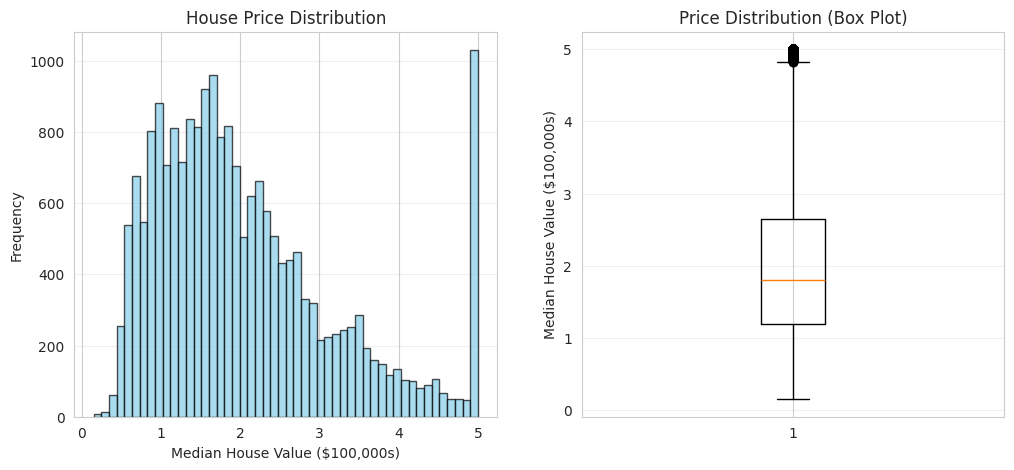

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df['target'], bins=50, edgecolor='black', color='skyblue', alpha=0.7)
axes[0].set_xlabel('Median House Value ($100,000s)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('House Price Distribution')
axes[0].grid(axis='y', alpha=0.3)

axes[1].boxplot(df['target'], vert=True)
axes[1].set_ylabel('Median House Value ($100,000s)')
axes[1].set_title('Price Distribution (Box Plot)')
axes[1].grid(axis='y', alpha=0.3)


In [116]:
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.close()
print("[STEP 2] Creating demographic groups...")

[STEP 2] Creating demographic groups...


# Income groups for fairness analysis

In [117]:
df['income_group'] = pd.cut(df['MedInc'],
                             bins=[0, 2, 4, 6, 100],
                             labels=['Low', 'Medium', 'High', 'Very High'])


In [118]:
# Geographic regions (redlining test)
df['region'] = pd.cut(df['Latitude'],
                       bins=[32, 35, 37.5, 40, 42],
                       labels=['South', 'Central', 'North', 'Far North'])


In [119]:
print(f"Income groups: {df['income_group'].value_counts().sort_index().to_dict()}")
print(f"Regions: {df['region'].value_counts().sort_index().to_dict()}")


Income groups: {'Low': 2457, 'Medium': 10096, 'High': 5725, 'Very High': 2362}
Regions: {'South': 11294, 'Central': 3211, 'North': 5723, 'Far North': 412}


Text(0, 0.5, 'House Value ($100,000s)')

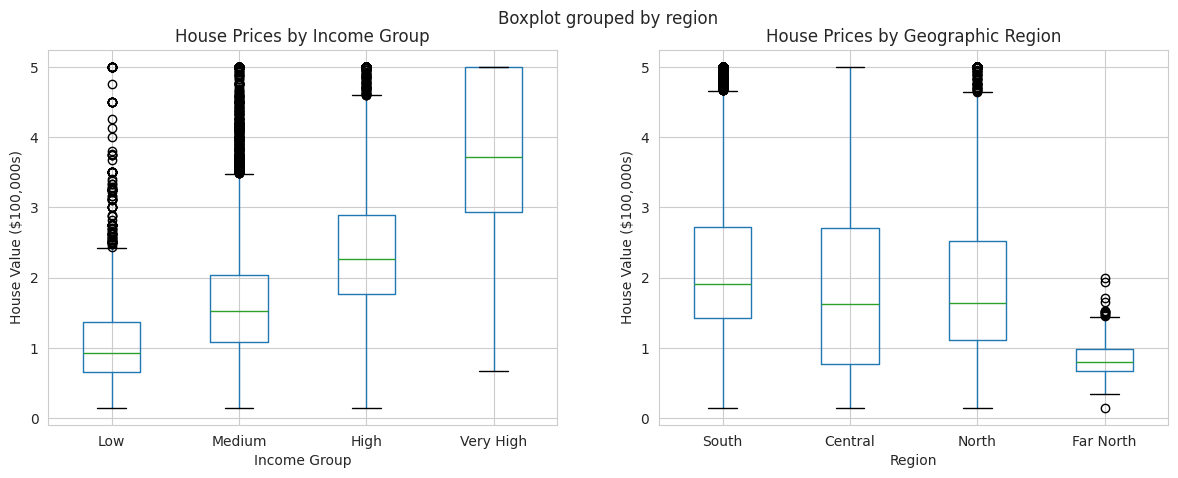

In [120]:
# Visualize demographic disparities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.boxplot(column='target', by='income_group', ax=axes[0])
axes[0].set_title('House Prices by Income Group')
axes[0].set_xlabel('Income Group')
axes[0].set_ylabel('House Value ($100,000s)')

df.boxplot(column='target', by='region', ax=axes[1])
axes[1].set_title('House Prices by Geographic Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('House Value ($100,000s)')


In [121]:
plt.suptitle('')
plt.tight_layout()
plt.savefig('demographic_bias_preview.png', dpi=300, bbox_inches='tight')
plt.close()

print("\n[STEP 3] Preparing data for modeling...")


[STEP 3] Preparing data for modeling...


# Split features and target

In [122]:
X = df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']]
y = df['target']

In [123]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [124]:

print(f"Train: {X_train.shape[0]:,}, Test: {X_test.shape[0]:,}")

Train: 16,512, Test: 4,128


In [125]:
# Save data for subsequent notebooks
df.to_csv('california_housing_with_groups.csv', index=False)
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False, header=['target'])
y_test.to_csv('y_test.csv', index=False, header=['target'])

print("\n✓ Exploration complete. Outputs:")
print("  - correlation_heatmap.png")
print("  - target_distribution.png")
print("  - demographic_bias_preview.png")
print("  - california_housing_with_groups.csv")


✓ Exploration complete. Outputs:
  - correlation_heatmap.png
  - target_distribution.png
  - demographic_bias_preview.png
  - california_housing_with_groups.csv
